In [40]:
import numpy as np
import random
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(42)
random.seed(42)


## Task 3

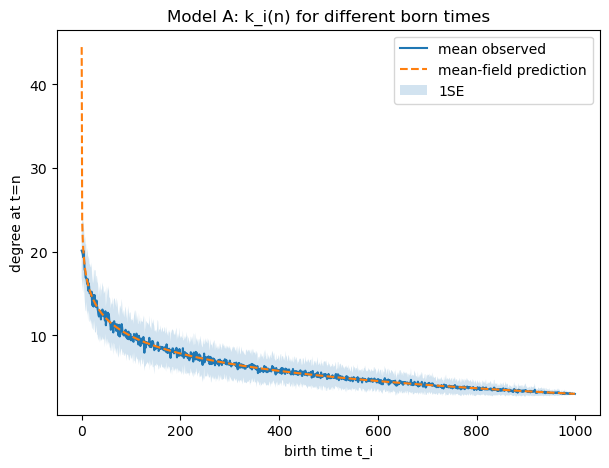

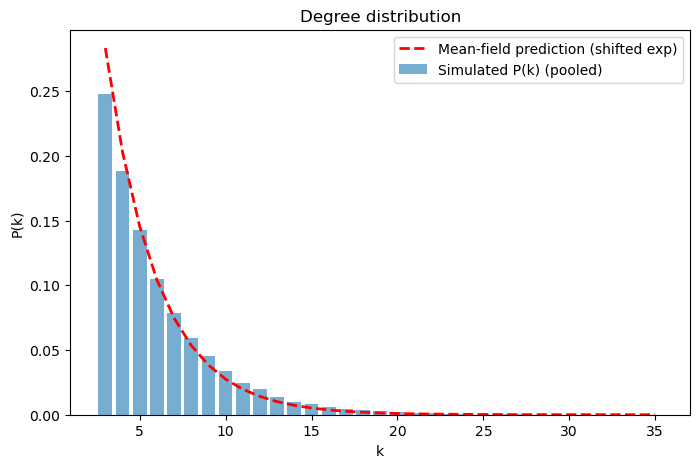

In [41]:
# A model

def simulate_random_attachment(n, m, m0=3):
    # start with complete graph
    G = nx.complete_graph(m0)
    degrees = np.array([G.degree(i) for i in G.nodes()])
    birth_times = np.arange(m0)  # t_i for initial nodes

    for t in range(m0, n):
        G.add_node(t)
        # choose m distinct targets uniformly at random from existing nodes
        targets = random.sample(list(G.nodes())[:-1], m)
        for target in targets:
            G.add_edge(t, target)
        degrees = np.array([G.degree(i) for i in G.nodes()])
        birth_times = np.append(birth_times, t)

    return degrees, birth_times

def ensemble_degrees_all(n, m, m0=3, R=50):
    degrees_all = np.zeros((R, n), dtype=int)
    for r in range(R):
        # simulate one run and collect final degrees at t=n
        G = nx.complete_graph(m0)
        for t in range(m0, n):
            G.add_node(t)
            targets = random.sample(list(G.nodes())[:-1], m)
            for target in targets:
                G.add_edge(t, target)
        degs = np.array([G.degree(i) for i in range(n)], dtype=int)
        degrees_all[r, :] = degs
    return degrees_all

def ensemble_avg_random(degrees_all):
    mean_deg = degrees_all.mean(axis=0)
    se_deg = degrees_all.std(axis=0)
    t_i = np.arange(n)
    return mean_deg, se_deg, t_i

n = 1000
m = 3 # attached noeds
m0 = 3 # initial nodes
R = 50 # repeat
eps = 1e-3 # for division

degrees_all = ensemble_degrees_all(n, m, m0, R)
mean_deg, se_deg, t_i = ensemble_avg_random(degrees_all)
t = n 
k_pred = m * np.log(t / (t_i + eps)) + m

plt.figure(figsize=(7,5))
plt.plot(t_i, mean_deg, label='mean observed')
plt.plot(t_i, k_pred, '--', label='mean-field prediction')
plt.fill_between(t_i, mean_deg - se_deg, mean_deg + se_deg, alpha=0.2, label='1SE')
plt.xlabel('birth time t_i')
plt.ylabel('degree at t=n')
plt.legend()
plt.title("Model A: k_i(n) for different born times")
plt.show()


pooled = degrees_all.ravel()  # all degrees across runs and nodes (flattened - pooled)

k_min = pooled.min()
k_max = pooled.max()
k_space = np.arange(k_min, k_max+1)

P_theory = (np.e/m) * np.exp(-k_space/m)
P_theory[k_space < m] = 0
# normalization
P_theory = P_theory / P_theory.sum()

counts, bins = np.histogram(pooled, bins=np.arange(k_min-0.5, k_max+1.5, 1.0))
P_emp = counts / counts.sum()

plt.figure(figsize=(8,5))
plt.bar(k_space, P_emp, width=0.8, alpha=0.6, label='Simulated P(k) (pooled)')
plt.plot(k_space, P_theory, 'r--', lw=2, label='Mean-field prediction (shifted exp)')
plt.xlabel('k')
plt.ylabel('P(k)')
plt.legend()
plt.title('Degree distribution')
plt.show()

## Task 4

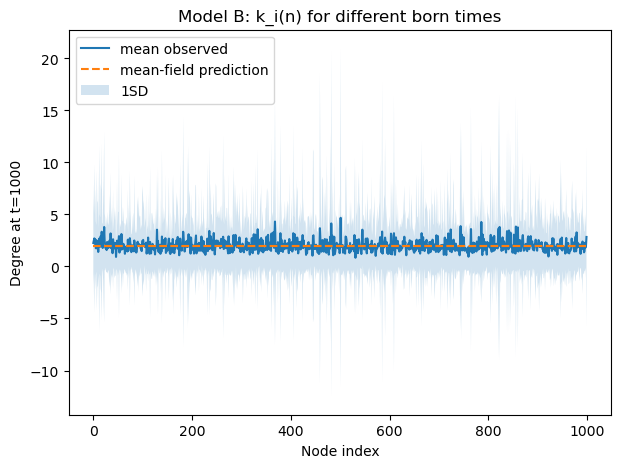

In [42]:
# Check with simulations result obtained for model B.

def fixed_size_b_model(N=100, m_steps=1000, R=50):
    mean_deg_all = np.zeros(N)
    se_deg_all = np.zeros(N)
    
    for r in range(R):
        # start with N isolated nodes
        G = nx.empty_graph(N)
        degrees = np.zeros(N)
        stubs = []  # list of node indices repeated by degree (for preferential attachment)
        # if a node gets a new connection, it is added to the list (potentially many times) so prob. of selecting it is proportional to its degree
        
        for t in range(m_steps):
            # pick first node uniformly
            u = random.randrange(N)
            # pick second node preferentially
            if stubs:
                v = random.choice(stubs)
            else:
                v = random.randrange(N)
            # avoid self-loop
            if u == v:
                continue
            G.add_edge(u, v)
            degrees[u] += 1
            degrees[v] += 1
            stubs.extend([u, v])
        
        mean_deg_all += degrees
        se_deg_all += degrees**2
    
    mean_deg = mean_deg_all / R
    std_deg = np.sqrt(se_deg_all / R - mean_deg**2)
    return mean_deg, std_deg

N = 1000
m_steps = 1000
R = 50
mean_deg, std_deg = fixed_size_b_model(N, m_steps, R)

# Mean-field prediction: k_i(t) ~ 2/N * t
t = m_steps
k_pred = 2 / N * t * np.ones(N)

# Plot
plt.figure(figsize=(7,5))
plt.plot(range(N), mean_deg, '-', label='mean observed')
plt.plot(range(N), k_pred, '--', label='mean-field prediction')
plt.fill_between(range(N), mean_deg - std_deg, mean_deg + std_deg, alpha=0.2, label='1SD')
plt.xlabel('Node index')
plt.ylabel(f'Degree at t={t}')
plt.legend()
plt.title("Model B: k_i(n) for different born times")
plt.show()